In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: Set a nice visual theme for our graphs
sns.set_theme(style="whitegrid")

# Load Trades Data
trades_d1 = pd.read_csv('../datasets/round4/trades_round_4_day_1.csv', sep=';')
trades_d2 = pd.read_csv('../datasets/round4/trades_round_4_day_2.csv', sep=';')
trades_d3 = pd.read_csv('../datasets/round4/trades_round_4_day_3.csv', sep=';')

# Add day identifiers
trades_d1['day'] = 1
trades_d2['day'] = 2
trades_d3['day'] = 3

# Combine into a single dataframe
all_trades = pd.concat([trades_d1, trades_d2, trades_d3], ignore_index=True)

# Load Prices for Day 1 as an example for our price overlay graph
prices_d1 = pd.read_csv('../datasets/round4/prices_round_4_day_1.csv', sep=';')

print("Unique Bots in Market:", all_trades['buyer'].unique())
print("Market Products:", all_trades['symbol'].unique())

Unique Bots in Market: <StringArray>
['Mark 01', 'Mark 38', 'Mark 55', 'Mark 67', 'Mark 14', 'Mark 22', 'Mark 49']
Length: 7, dtype: str
Market Products: <StringArray>
[           'VEV_5400',            'VEV_5500',            'VEV_6000',
            'VEV_6500',       'HYDROGEL_PACK',            'VEV_4000',
 'VELVETFRUIT_EXTRACT',            'VEV_5300',            'VEV_5200',
            'VEV_4500',            'VEV_5000',            'VEV_5100']
Length: 12, dtype: str


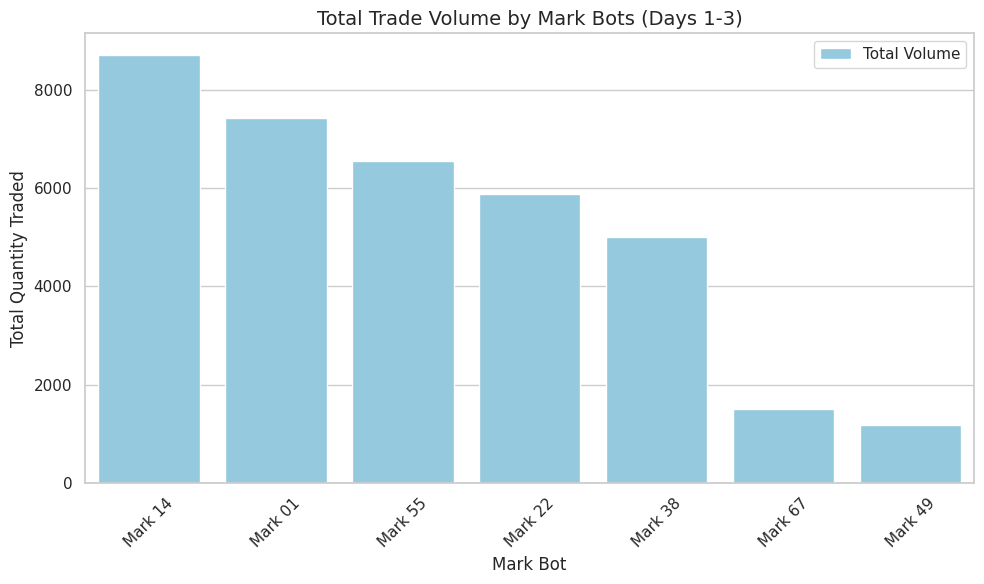

In [4]:
# Calculate total volume bought and sold by each bot
buy_volume = all_trades.groupby('buyer')['quantity'].sum().reset_index().rename(columns={'buyer': 'Bot', 'quantity': 'Bought'})
sell_volume = all_trades.groupby('seller')['quantity'].sum().reset_index().rename(columns={'seller': 'Bot', 'quantity': 'Sold'})

# Merge and calculate total volume
bot_volumes = pd.merge(buy_volume, sell_volume, on='Bot', how='outer').fillna(0)
bot_volumes['Total Volume'] = bot_volumes['Bought'] + bot_volumes['Sold']
bot_volumes = bot_volumes.sort_values('Total Volume', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=bot_volumes, x='Bot', y='Total Volume', color='skyblue', label='Total Volume')
plt.title('Total Trade Volume by Mark Bots (Days 1-3)', fontsize=14)
plt.xlabel('Mark Bot')
plt.ylabel('Total Quantity Traded')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

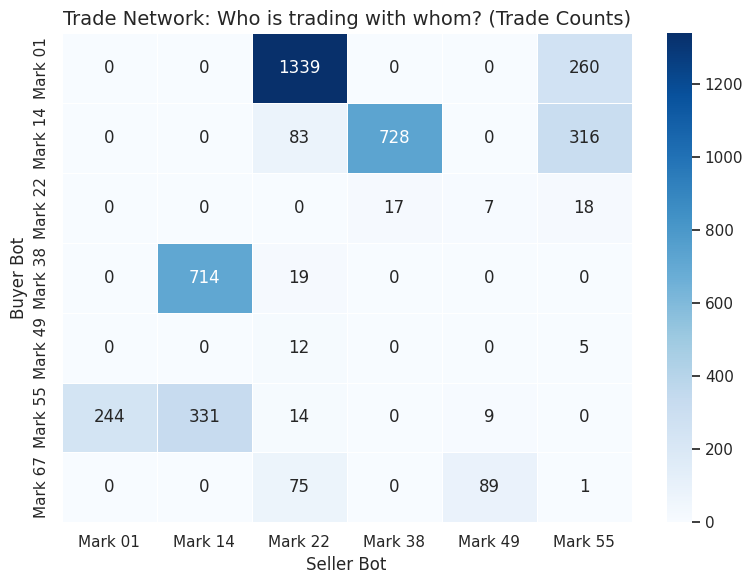

In [5]:
plt.figure(figsize=(8, 6))

# Create a cross-tabulation of buyers vs. sellers based on number of trades
heatmap_data = pd.crosstab(all_trades['buyer'], all_trades['seller'])

# Plot heatmap
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='Blues', linewidths=.5)
plt.title('Trade Network: Who is trading with whom? (Trade Counts)', fontsize=14)
plt.xlabel('Seller Bot')
plt.ylabel('Buyer Bot')
plt.tight_layout()
plt.show()

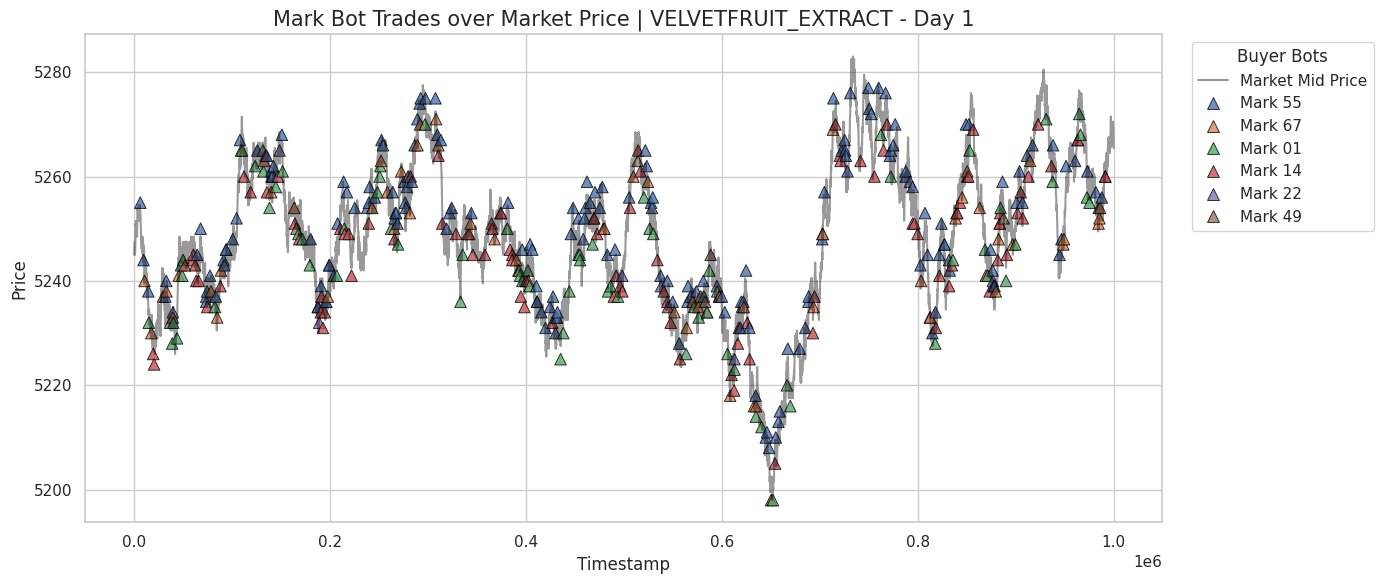

In [6]:
def plot_bot_trades(product, day_trades, day_prices, day_num):
    plt.figure(figsize=(14, 6))

    # Filter data for the specific product
    trades_prod = day_trades[day_trades['symbol'] == product]
    prices_prod = day_prices[day_prices['product'] == product]

    # 1. Plot the continuous mid_price of the asset
    plt.plot(prices_prod['timestamp'], prices_prod['mid_price'], 
             label='Market Mid Price', color='black', alpha=0.4, linewidth=1.5)

    # 2. Scatter plot for Buyers (Upward triangles)
    sns.scatterplot(data=trades_prod, x='timestamp', y='price', 
                    hue='buyer', marker='^', s=70, edgecolor='black', alpha=0.8)

    plt.title(f'Mark Bot Trades over Market Price | {product} - Day {day_num}', fontsize=15)
    plt.xlabel('Timestamp')
    plt.ylabel('Price')
    
    # Format the legend to sit outside the plot
    plt.legend(title='Buyer Bots', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Execute the function for Day 1 Velvetfruit Extract
plot_bot_trades('VELVETFRUIT_EXTRACT', trades_d1, prices_d1, 1)